In [1]:
import string
import textwrap

import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting

In [2]:
def load_metrics_from_wandb(run, keys):
    history = pd.DataFrame(run.scan_history(keys=keys))
    ds = xr.Dataset.from_dataframe(history)
    ds = ds.rename({"index": "time"})
    ds["time"] = xr.date_range("2031-01-01T12", periods=ds.sizes["time"], freq="6h")
    ds = ds.assign_coords(time=ds.time)
    return ds.rename({s: s.rsplit('/', 1)[-1] for s in ds.data_vars})


def load_panel_a_data():
    wandb_entity = "ai2cm"
    wandb_project = "ace-som"

    run_ids = {
        "1xCO2": "j5utrc0j",
        "2xCO2": "055d8zqy",
        "4xCO2": "jtr9rh3t",
    }

    api = wandb.Api()

    runs = {}
    for name, id in run_ids.items():
        runs[name] = api.run(f"{wandb_entity}/{wandb_project}/{id}")

    variable_names = ["implied_tendency_of_total_energy_ace2_path_due_to_advection"]
    metric_names = [f"inference/mean/weighted_mean_gen/{var}" for var in variable_names]

    datasets = {}
    for climate, run in runs.items():
        datasets[climate] = load_metrics_from_wandb(run, metric_names)
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="climate"))


def load_panel_b_data():
    wandb_entity = "ai2cm"
    wandb_project = "ace-shield"

    run_ids = {
        "SHiELD-SOM": "iuus17rq",
        "full-rs1": "hexojja2",
        "full-energy-conserving-rs0": "7a7e584r",
    }

    api = wandb.Api()

    runs = {}
    for name, id in run_ids.items():
        runs[name] = api.run(f"{wandb_entity}/{wandb_project}/{id}")

    variable_names = ["implied_tendency_of_total_energy_ace2_path_due_to_advection"]
    metric_names = [f"inference/mean/weighted_mean_gen/{var}" for var in variable_names]

    datasets = {}
    for case, run in runs.items():
        datasets[case] = load_metrics_from_wandb(run, metric_names)
    return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="case"))

In [13]:
LABELS = {
    "1xCO2": "1xCO$_2$",
    "2xCO2": "2xCO$_2$",
    "4xCO2": "4xCO$_2$",
}
COLORS = {
    "full-rs1": "C5",
    "SHiELD-SOM": "k",
    "full-energy-conserving-rs0": "C4",
}
CASE_LABELS = {
    "SHiELD-SOM": "SHiELD-SOM",
    "full-rs1": textwrap.fill("ACE2S-SHiELD+ w/ random CO$_2$ w/o energy conservation", width=35),
    "full-energy-conserving-rs0": textwrap.fill("ACE2S-SHiELD+ w/ random CO$_2$ w/ energy conservation", width=35),
}

In [4]:
plotting.configure_style()

In [5]:
ds_a = load_panel_a_data()
ds_b = load_panel_b_data()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/spencerc/.netrc.
/tmp/ipykernel_13864/4101478991.py:57: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  return xr.concat(datasets.values(), dim=pd.Index(datasets.keys(), name="case"))


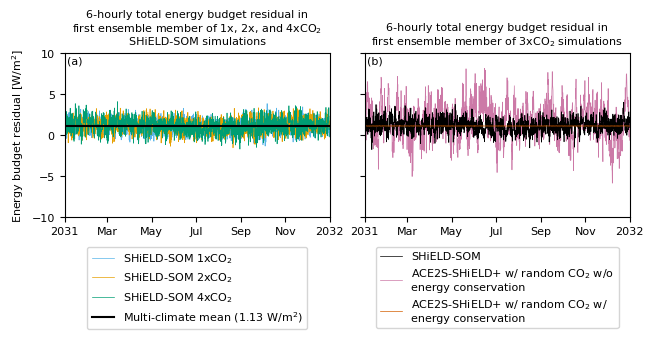

In [17]:
fig, (ax1, ax2) = faceted.faceted(1, 2, width=6.5, aspect=0.618, internal_pad=0.35, bottom_pad=1.2, top_pad=0.5, left_pad=0.6)

for climate, label in LABELS.items():
    ds_a.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(time="2031", climate=climate).plot(ax=ax1, lw=0.5, label=f"SHiELD-SOM {label}")

ax1.axhline(1.13, color="k", label="Multi-climate mean (1.13 W/m$^2$)")
ax1.set_xlabel("")
ax1.set_ylabel(textwrap.fill("Energy budget residual [W/m$^2$]", width=35))
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15))
ax1.set_title(textwrap.fill("6-hourly total energy budget residual in first ensemble member of 1x, 2x, and 4xCO$_2$ SHiELD-SOM simulations", width=45))

for case, color in COLORS.items():
    ds_b.implied_tendency_of_total_energy_ace2_path_due_to_advection.sel(time="2031", case=case).plot(ax=ax2, lw=0.5, color=color, label=CASE_LABELS[case])

ax2.set_title(textwrap.fill("6-hourly total energy budget residual in first ensemble member of 3xCO$_2$ simulations", width=45))
ax2.set_ylabel("")

handles, labels = ax2.get_legend_handles_labels()
handle_order = ["SHiELD-SOM", "full-rs1", "full-energy-conserving-rs0"]
label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[CASE_LABELS[case]] for case in handle_order]
ordered_labels = [CASE_LABELS[case] for case in handle_order]
ax2.legend(ordered_handles, ordered_labels, loc="upper center", bbox_to_anchor=(0.5, -0.15))

for ax in (ax1, ax2):
    ax.set_ylim(-10, 10)
    # ax.axhline(0.0, color="gray", ls="--", lw=0.33)
    ax.set_xlabel("")
    ax.set_xlim(np.datetime64("2031"), np.datetime64("2032"))

for ax, label in zip((ax1, ax2), string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.patch.set_alpha(0.0)
fig.savefig("figure-A01.png", dpi=200)
fig.savefig("figure-A01.pdf")
